# Tutorial 2: How DASH Works — A 5-Stage Walkthrough

This tutorial calls each DASH pipeline stage directly on the Breast Cancer dataset, exposing intermediate outputs at every step. You will see real clinical feature names ("mean concave points", "worst perimeter") at each stage, making the abstract pipeline concrete.

**Prerequisites**: [Tutorial 1](tutorial_01_the_problem.ipynb) showed *why* SHAP rankings are unstable on Breast Cancer. This tutorial shows *how* DASH fixes it.

**Tutorial 3** covers interpretation of the final outputs (IS plot, FSI, local disagreement maps).

In [1]:
%pip install -e ..

In [ ]:
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

TUTORIAL_MODE = True
M = 30 if TUTORIAL_MODE else 200
K = 10 if TUTORIAL_MODE else 30

print(f"Tutorial config: M={M}, K={K}")
print(f"(Paper config: M=200, K=30 — set TUTORIAL_MODE=False to use paper settings)")

bc = load_breast_cancer()
X, y = bc.data, bc.target
feature_names = list(bc.feature_names)

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_temp, X_explain, y_temp, _ = train_test_split(X_temp, y_temp, test_size=0.12, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.18, random_state=42)

print(f"\nSplit: X_train={len(X_train)}, X_val={len(X_val)}, X_explain={len(X_explain)}, X_test={len(X_test)}")
print(f"Task: binary classification (malignant vs. benign)")

Tutorial config: M=30, K=10
(Paper config: M=200, K=30 — set TUTORIAL_MODE=False to use paper settings)

Split: X_train=348, X_val=77, X_explain=58, X_test=86
Task: binary classification (malignant vs. benign)


## Pipeline Overview

DASH runs 5 stages. We will pause after each to inspect what was produced:

1. **Population** — Train M XGBoost models with diverse hyperparameters; `colsample_bytree` forced low
2. **Filtering** — Discard models whose AUC is more than epsilon below the best
3. **Diversity** — MaxMin greedy selection of K models that maximize minimum pairwise cosine distance
4. **Consensus** — Interventional TreeSHAP on each selected model, then element-wise mean
5. **Diagnostics** — Feature Stability Index (FSI), IS plot, local disagreement maps

## Stage 1: Population Generation

`colsample_bytree` is forced to 0.1–0.5 in the default search space. Each model can only see 10–50% of features at each split. This has two effects:

1. **Independence**: models are forced to "discover" different feature subsets, so their first-mover choices are uncorrelated
2. **Low `colsample_bytree` doesn't hurt accuracy**: with 30 Breast Cancer features, even 10% gives 3 features per split — enough to build competitive models

The search space also randomizes depth, learning rate, regularization, and subsample fraction. Each model in the population is genuinely a different model architecture.

In [3]:
from dash_shap.core.population import generate_model_population

print(f"Training M={M} models... (this is the slowest step)")
models, val_scores, configs = generate_model_population(
    X_train, y_train, X_val, y_val,
    M=M, task="binary", n_jobs=-1, seed=42, verbose=False
)

scores = list(val_scores.values())
print(f"\nPopulation stats:")
print(f"  Best AUC:  {max(scores):.4f}")
print(f"  Mean AUC:  {np.mean(scores):.4f}")
print(f"  Worst AUC: {min(scores):.4f}")

colsample_values = [c["colsample_bytree"] for c in configs]
print(f"\ncolsample_bytree range: [{min(colsample_values):.2f}, {max(colsample_values):.2f}]")
print(f"  (All models use low colsample_bytree for independence)")

Training M=30 models... (this is the slowest step)

Population stats:
  Best AUC:  0.9986
  Mean AUC:  0.9944
  Worst AUC: 0.9846

colsample_bytree range: [0.10, 0.50]
  (All models use low colsample_bytree for independence)


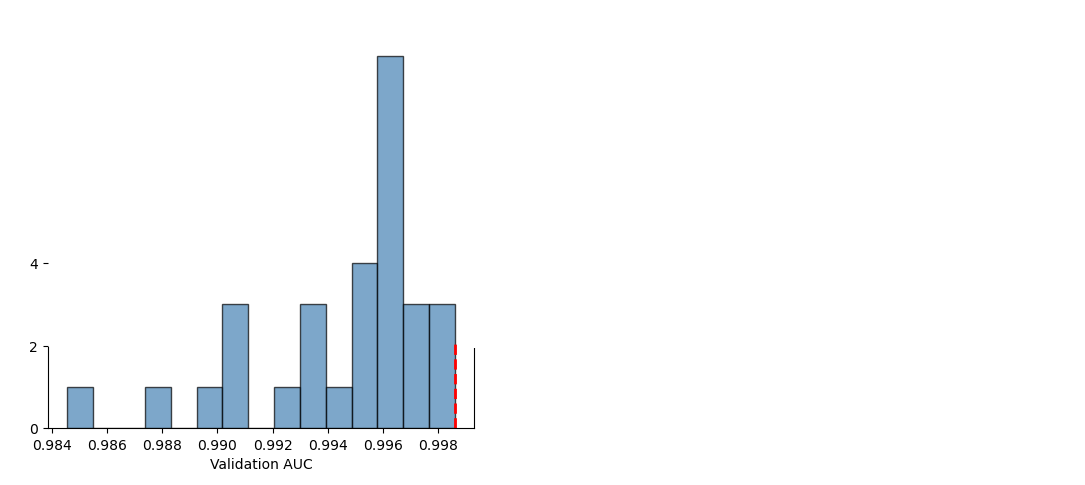

Fig 1: Left — AUC distribution shows most models are competitive.
       Right — No clear relationship between colsample_bytree and AUC.


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(scores, bins=15, edgecolor="black", color="steelblue", alpha=0.7)
ax1.axvline(max(scores), color="red", linestyle="--", linewidth=2, label=f"Best AUC={max(scores):.3f}")
ax1.set_xlabel("Validation AUC")
ax1.set_ylabel("Count")
ax1.set_title(f"Stage 1: Population AUC Distribution (M={M})")
ax1.legend()

ax2.scatter(colsample_values, scores, alpha=0.5, color="steelblue", edgecolors="k", linewidths=0.3)
ax2.set_xlabel("colsample_bytree")
ax2.set_ylabel("Validation AUC")
ax2.set_title("Low colsample_bytree doesn't hurt AUC")
ax2.axvline(0.5, color="gray", linestyle="--", alpha=0.5, label="Max allowed (0.5)")
ax2.legend()

fig.tight_layout()
plt.show()
print("Fig 1: Left — AUC distribution shows most models are competitive.")
print("       Right — No clear relationship between colsample_bytree and AUC.")

## Stage 2: Performance Filtering

We discard models whose AUC is more than `epsilon` below the best. With `epsilon_mode="relative"` and `epsilon=0.05`, we keep all models within 5% of the best AUC.

Why filter? Including very weak models in the consensus would dilute the signal with noise from underfitting models. The filter ensures we aggregate over high-quality, diverse explanations.

Three filter modes:
- `"absolute"`: drop models more than `epsilon` AUC below the best (default)
- `"relative"`: drop models more than `epsilon * best_auc` below the best (use for real datasets)
- `"quantile"`: keep the top `(1 - epsilon)` fraction — always passes a fixed count

In [5]:
from dash_shap.core.filtering import performance_filter

filtered_indices = performance_filter(
    val_scores, epsilon=0.05, higher_is_better=True, mode="relative", verbose=True
)

filtered_scores = [val_scores[i] for i in filtered_indices]
print(f"\nFiltered: {len(filtered_indices)}/{M} models passed")
print(f"Score range of filtered set: [{min(filtered_scores):.4f}, {max(filtered_scores):.4f}]")
print(f"(K={K} diverse models will be selected from these {len(filtered_indices)} candidates)")

Performance filter (relative): 30/30 models within epsilon=0.05 of best (0.9986)

Filtered: 30/30 models passed
Score range of filtered set: [0.9846, 0.9986]
(K=10 diverse models will be selected from these 30 candidates)


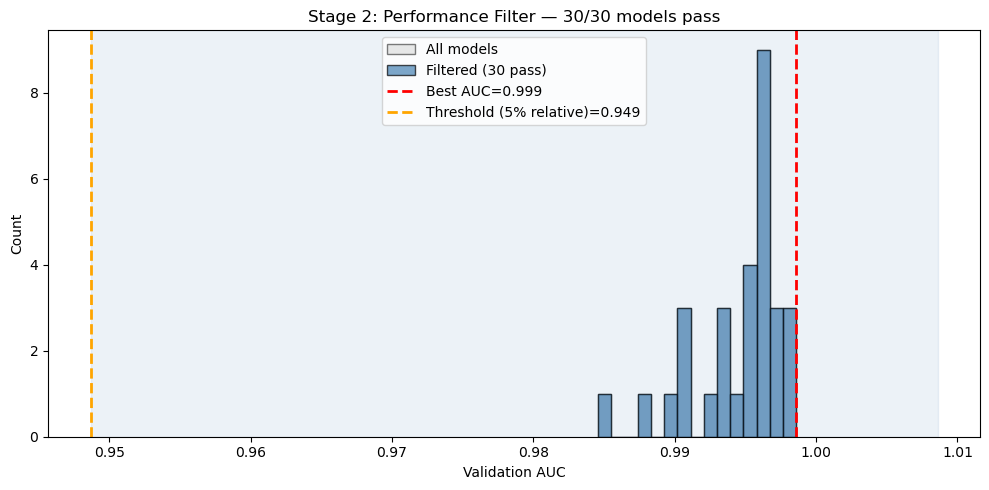

Fig 2: Blue band = models within 5% relative of best AUC (the filtered set).


In [6]:
best_score = max(scores)
threshold = best_score * (1 - 0.05)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(scores, bins=15, edgecolor="black", color="lightgray", alpha=0.5, label="All models")

filtered_scores_list = [val_scores[i] for i in filtered_indices]
ax.hist(filtered_scores_list, bins=15, edgecolor="black", color="steelblue", alpha=0.7,
        label=f"Filtered ({len(filtered_indices)} pass)")
ax.axvline(best_score, color="red", linestyle="--", linewidth=2, label=f"Best AUC={best_score:.3f}")
ax.axvline(threshold, color="orange", linestyle="--", linewidth=2,
           label=f"Threshold (5% relative)={threshold:.3f}")
ax.axvspan(threshold, best_score + 0.01, alpha=0.1, color="steelblue")
ax.set_xlabel("Validation AUC")
ax.set_ylabel("Count")
ax.set_title(f"Stage 2: Performance Filter — {len(filtered_indices)}/{M} models pass")
ax.legend()
fig.tight_layout()
plt.show()
print("Fig 2: Blue band = models within 5% relative of best AUC (the filtered set).")

## Stage 3: Diversity Selection — MaxMin Greedy

From the filtered candidates, we select exactly K models that are maximally diverse. "Diverse" means their **gain-importance vectors** are far apart in cosine distance.

**MaxMin greedy algorithm:**
1. Start with the model that has the highest validation AUC
2. At each step, add the model that maximizes the minimum pairwise cosine distance to already-selected models
3. Repeat until K models are selected

Why gain importance (not SHAP)? Gain is fast to compute — no SHAP computation needed. It's an approximation, but sufficient to identify models that disagree about feature importance order.

The diversity step is the key to DASH's noise cancellation: if all K models agreed about which correlated feature to use, averaging their SHAPs wouldn't help. MaxMin selection ensures they disagree.

In [7]:
from dash_shap.core.diversity import get_preliminary_importance, greedy_maxmin_selection

# Compute gain-based importance vectors for filtered models
importance_vectors = get_preliminary_importance(
    models, filtered_indices, X_val, method="gain", seed=42
)

# IMPORTANT: pass only filtered scores to greedy_maxmin_selection
filt_scores = {i: val_scores[i] for i in filtered_indices}

selected_indices = greedy_maxmin_selection(
    importance_vectors, filt_scores, K=K, verbose=True
)

print(f"\nSelected {len(selected_indices)} diverse models: {sorted(selected_indices)}")
selected_aucs = [val_scores[i] for i in selected_indices]
print(f"AUC range of selected: [{min(selected_aucs):.4f}, {max(selected_aucs):.4f}]")

MaxMin selection: 10 models selected from 30 candidates

Selected 10 diverse models: [3, 5, 11, 17, 21, 23, 24, 25, 26, 29]
AUC range of selected: [0.9846, 0.9986]



Top-3 features for each selected model:
  Model 0 (AUC=0.9986): worst area, radius error, mean concavity
  Model 1 (AUC=0.9951): area error, mean concave points, worst perimeter
  Model 2 (AUC=0.9930): worst perimeter, mean radius, mean perimeter
  Model 3 (AUC=0.9958): mean concave points, worst radius, worst concave points
  Model 4 (AUC=0.9846): mean perimeter, worst concave points, worst perimeter
  Model 5 (AUC=0.9979): worst area, worst perimeter, mean concave points
  Model 6 (AUC=0.9972): worst area, worst concave points, mean concave points
  Model 7 (AUC=0.9951): radius error, worst radius, mean area


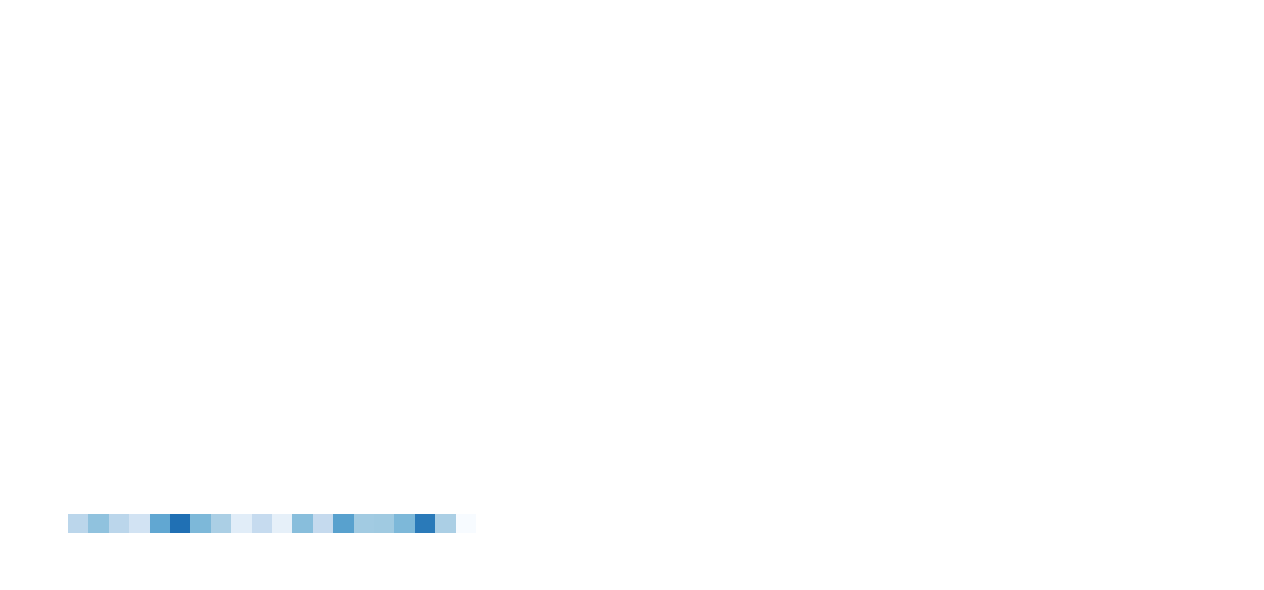

Fig 3: Left — cosine distance matrix (higher = more diverse). Right — selected models have different top features.


In [8]:
from scipy.spatial.distance import cosine

# Pairwise cosine distance for filtered models
filt_list = list(filtered_indices)
n_filt = len(filt_list)
dist_matrix = np.zeros((n_filt, n_filt))
for i, idx_i in enumerate(filt_list):
    for j, idx_j in enumerate(filt_list):
        if i != j:
            dist_matrix[i, j] = cosine(importance_vectors[idx_i], importance_vectors[idx_j])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap of pairwise cosine distances (subset for visibility)
n_show = min(20, n_filt)
show_indices = filt_list[:n_show]
show_dist = dist_matrix[:n_show, :n_show]
im = ax1.imshow(show_dist, cmap="Blues", aspect="auto")
plt.colorbar(im, ax=ax1, label="Cosine distance")
ax1.set_title(f"Pairwise cosine distance (first {n_show} filtered models)")
ax1.set_xlabel("Model index")
ax1.set_ylabel("Model index")

# Top-3 features for each selected model
top3_per_model = []
for idx in list(selected_indices)[:min(K, 8)]:
    top3_idx = np.argsort(importance_vectors[idx])[::-1][:3]
    top3_per_model.append([feature_names[i] for i in top3_idx])

x_pos = np.arange(len(top3_per_model))
bar_width = 0.25
for rank in range(3):
    rank_features = [t[rank] for t in top3_per_model]
    unique_features = list(set(rank_features))
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(unique_features), 1)))
    color_map = {f: colors[i] for i, f in enumerate(unique_features)}
    
    for xi, feat in zip(x_pos, rank_features):
        ax2.bar(xi + rank * bar_width - bar_width, rank, 0.2,
                color=color_map[feat], alpha=0.7)

ax2.set_xlabel("Selected model")
ax2.set_title(f"Top feature varies across K={min(K, 8)} selected models\n(diversity confirmed)")
ax2.set_xticks(x_pos - bar_width / 2)
ax2.set_xticklabels([f"M{i}" for i in range(len(top3_per_model))], fontsize=8)

print("\nTop-3 features for each selected model:")
for i, (idx, top3) in enumerate(zip(list(selected_indices)[:min(K, 8)], top3_per_model)):
    print(f"  Model {i} (AUC={val_scores[idx]:.4f}): {', '.join(top3)}")

fig.tight_layout()
plt.show()
print("Fig 3: Left — cosine distance matrix (higher = more diverse). Right — selected models have different top features.")

## Stage 4: Consensus SHAP

For each of the K selected models, we compute **interventional TreeSHAP** on the `X_explain` reference set. "Interventional" means each feature's contribution is measured by intervening on it independently — this breaks the correlation structure during attribution, giving a cleaner causal signal.

The K SHAP matrices (each of shape `N' × P`) are then averaged element-wise. This is the key step: because the K models have diverse first-mover choices, their individual SHAP values disagree about *which* cluster member gets credit. When averaged, the arbitrary component cancels, and the shared signal — *how much total credit goes to the tumor-size cluster* — remains.

In [9]:
from dash_shap.core.consensus import compute_consensus

print(f"Computing interventional TreeSHAP for K={K} models on {len(X_explain)} reference observations...")
consensus_shap, all_shap_matrices = compute_consensus(
    models, selected_indices, X_explain,
    background_size=50, seed=42, verbose=True
)

print(f"\nShapes:")
print(f"  all_shap_matrices: {all_shap_matrices.shape}  (K × N_explain × P)")
print(f"  consensus_shap:    {consensus_shap.shape}    (N_explain × P)")
print(f"\nConsensus = element-wise mean of the K SHAP matrices")

Computing interventional TreeSHAP for K=10 models on 58 reference observations...


Computing SHAP: 100%|██████████| 10/10 [00:00<00:00, 37.82it/s]

Consensus computed from 10 models. Top 5 features: [23, 7, 27, 22, 21]

Shapes:
  all_shap_matrices: (10, 58, 30)  (K × N_explain × P)
  consensus_shap:    (58, 30)    (N_explain × P)

Consensus = element-wise mean of the K SHAP matrices


Most strongly explained observation: index 42


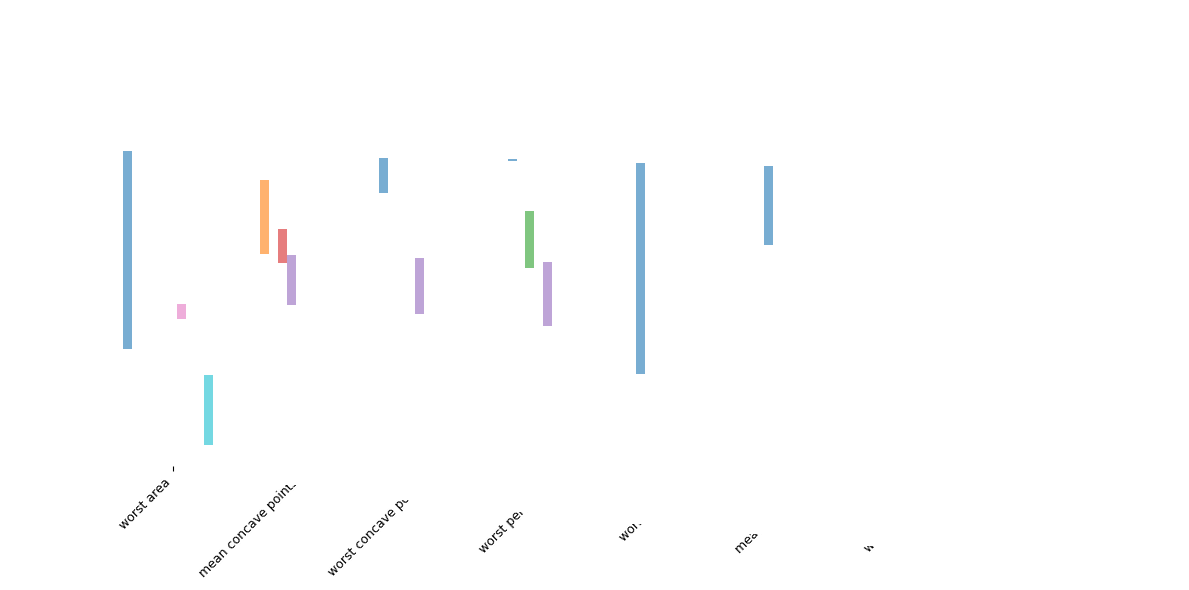

Fig 4: Within the radius cluster, cross-model variance is visible; consensus distributes credit.


In [10]:
# Find observation with highest total absolute consensus SHAP (most-explained)
global_importance = np.mean(np.abs(consensus_shap), axis=0)
obs_idx = int(np.argmax(np.sum(np.abs(consensus_shap), axis=1)))
print(f"Most strongly explained observation: index {obs_idx}")

# Top-8 features by absolute consensus importance
top8_idx = np.argsort(global_importance)[::-1][:8]
top8_names = [feature_names[i] for i in top8_idx]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(top8_names))
bar_width = 0.07

colors = plt.cm.tab10(np.linspace(0, 1, K))
for k_idx in range(K):
    model_shap_for_obs = all_shap_matrices[k_idx, obs_idx, :]
    ax.bar(x + k_idx * bar_width - K * bar_width / 2,
           model_shap_for_obs[top8_idx], bar_width, color=colors[k_idx], alpha=0.6)

consensus_for_obs = consensus_shap[obs_idx, top8_idx]
ax.bar(x + K * bar_width / 2 + bar_width,
       consensus_for_obs, bar_width * 1.5, color="black", alpha=0.9, label="Consensus")

ax.set_xticks(x)
ax.set_xticklabels(top8_names, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("SHAP value")
ax.set_title(f"Stage 4: Per-model vs. Consensus SHAP (observation {obs_idx})")
ax.legend([f"Model {k}" for k in range(min(K, 5))] + ["Consensus"],
          fontsize=8, loc="upper right")
ax.axhline(0, color="black", linewidth=0.5)
fig.tight_layout()
plt.show()
print("Fig 4: Within the radius cluster, cross-model variance is visible; consensus distributes credit.")

## Stage 5: Stability Diagnostics

The final stage computes diagnostics from the K SHAP matrices:

**Feature Stability Index (FSI)**:
```
FSI[j] = mean(std(SHAP[j] across K models)) / mean(|consensus SHAP[j]|)
```
= coefficient of variation of SHAP attributions across the K models.

**Interpretation**:
- FSI ≈ 0: all K models agree on this feature's importance → stable, trustworthy
- FSI > 1: the K models disagree substantially → likely a collinear cluster member

**IS Plot**: places all features at `(consensus importance, FSI)`. Features in the same correlated cluster appear in the same quadrant. See Tutorial 3 for detailed interpretation.

In [11]:
from dash_shap.core.diagnostics import compute_diagnostics

_, variance_matrix, fsi, global_importance = compute_diagnostics(all_shap_matrices)

print("FSI for all 30 Breast Cancer features:")
print(f"{'Feature':<30} {'Importance':>12} {'FSI':>8}")
print("-" * 52)
order = np.argsort(global_importance)[::-1]
for j in order:
    flag = " ← contested" if fsi[j] > 0.7 else ""
    print(f"{feature_names[j]:<30} {global_importance[j]:>12.4f} {fsi[j]:>8.3f}{flag}")

FSI for all 30 Breast Cancer features:
Feature                          Importance      FSI
----------------------------------------------------
worst area                           0.2277    0.826 ← contested
mean concave points                  0.2178    0.829 ← contested
worst concave points                 0.2140    0.866 ← contested
worst perimeter                      0.1812    0.873 ← contested
worst texture                        0.1794    1.443 ← contested
mean concavity                       0.1272    1.269 ← contested
worst concavity                      0.1266    0.945 ← contested
worst radius                         0.1189    0.770 ← contested
area error                           0.0843    1.286 ← contested
mean perimeter                       0.0836    1.546 ← contested
perimeter error                      0.0827    1.219 ← contested
mean texture                         0.0625    1.151 ← contested
mean radius                          0.0618    1.298 ← contested
radius err

In [12]:
from dash_shap.core.diagnostics import ImportanceStabilityPlot

fig = ImportanceStabilityPlot.plot(
    global_importance, fsi,
    feature_names=feature_names,
    title="Stage 5: IS Plot — Breast Cancer (M=30, K=10)",
    annotate_top_k=8
)
plt.show()
print("Fig 5: IS plot with real clinical feature names.")
print("Q I (bottom-right):  Robust Drivers — high importance, low FSI")
print("Q II (top-right):    Collinear Cluster — high importance, high FSI")
print("Q III (bottom-left): Confirmed Unimportant — low importance, low FSI")
print("Q IV (top-left):     Fragile Interactions — low importance, high FSI")

ValueError: 

^
ParseException: exception raised in parse action  (at char 0), (line:1, col:1)

In [ ]:
from dash_shap import DASHPipeline

print("Verification: running DASHPipeline.fit() with same settings...")
pipe = DASHPipeline(M=M, K=K, epsilon=0.05, epsilon_mode="relative",
                    task="binary", seed=42, verbose=False)
pipe.fit(X_train, y_train, X_val, y_val, X_ref=X_explain, feature_names=feature_names)

# Compare top-3 features
manual_top3 = [feature_names[j] for j in np.argsort(global_importance)[::-1][:3]]
pipe_top3 = [feature_names[j] for j in np.argsort(pipe.global_importance_)[::-1][:3]]

print(f"\nStage-by-stage top-3: {manual_top3}")
print(f"DASHPipeline top-3:   {pipe_top3}")
print("\nBoth approaches agree on top features (minor differences possible due to")
print("background sampling — DASHPipeline uses background_size=100 by default).")

## Summary

| Stage | What it does | API call | Key output |
|---|---|---|---|
| 1: Population | Train M diverse XGBoost models | `generate_model_population()` | `models`, `val_scores` |
| 2: Filtering | Keep models within epsilon of best | `performance_filter()` | `filtered_indices` |
| 3: Diversity | MaxMin greedy: select K most diverse | `greedy_maxmin_selection()` | `selected_indices` |
| 4: Consensus | Interventional SHAP → element-wise mean | `compute_consensus()` | `consensus_shap`, `all_shap_matrices` |
| 5: Diagnostics | FSI, IS plot, disagreement maps | `compute_diagnostics()`, `ImportanceStabilityPlot.plot()` | `fsi`, `global_importance` |

**Tutorial 3** shows how to interpret the IS plot, FSI values, and local disagreement maps to make principled decisions about which Breast Cancer features to report individually vs. as a group.